In [1]:
import sys
sys.path.insert(0, '../../')

In [2]:
import random
import os
from pickle import dump, load
from tqdm import tqdm

from sklearn.ensemble  import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor

from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

from sklearn.model_selection import train_test_split, KFold

from sklearn import svm
from sklearn.base import BaseEstimator

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

import pandas as pd
import numpy as np

from src.outlier_detection import find_outliers_remove
from src.config import params
from src.feature_selection import ModelSelection
from src.graph_visualization import feature_selection_tabularize

In [3]:
def select_model_classifier(model_name:str) -> BaseEstimator:
    if model_name=='KNN':
        return KNeighborsClassifier(metric='minkowski', 
                                    n_neighbors=params['KNN']['n_neighbors'], 
                                    weights=params['KNN']['weights'])

    elif model_name=='SVM':
        return SVC(C=params['SVM']['C'], 
                   gamma=params['SVM']['gamma'], 
                   kernel=params['SVM']['kernel'])
        
    elif model_name=='RF':
        return RandomForestClassifier(max_depth=params['RF']['max_depth'], 
                                      min_samples_leaf=params['RF']['min_samples_leaf'],\
                                      min_samples_split=params['RF']['min_samples_split'], 
                                      n_estimators=params['RF']['n_estimators'])


def get_best_score_per_feature_count(feature_scores: dict, only_best=True, higher_better=True):
    best_score_feature_set = []
    feature_scores = [feature_scores[-1]] if only_best else feature_scores

    for ind, feature_set in enumerate(feature_scores):
        feature_comb = list(feature_set.keys())
        scores       = list(feature_set.values())
        best_ind     = np.argmax(scores) if higher_better else np.argmin(scores)

        best_score_feature_set.append((('Prev + ' if ind!=0 else '') + eval(feature_comb[best_ind])[-1], scores[best_ind]))
        

    return best_score_feature_set[-1] if only_best else best_score_feature_set



def plot_model_vs_score(score_df:dict, 
                       metric='',
                       save_path='') -> None:     
    

    ax = score_df.plot(x='Models', y="Scores", kind='bar', legend=False)
    plt.legend()
    for i, p in enumerate(ax.patches):
        ax.annotate(str(round(p.get_height(), 4)), (p.get_x() + p.get_width() / 2., 0.3 * p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',  rotation='vertical', fontsize=10, )
    
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Feature set')
    plt.ylabel(metric)
    plt.legend().set_visible(False)
    if save_path!='':
        plt.savefig(f'{save_path}', dpi=300, bbox_inches='tight')
    
    

In [4]:
# Load Extracted features dataset
ML6_1 = pd.read_excel('../../dataset/ML6/Day 1 Data/feature_extraction_noise_None.xlsx')
ML6_2 = pd.read_excel('../../dataset/ML6/Day 2 Data/feature_extraction_noise_None.xlsx')

ML6_1['dataset_name'] = '1'
ML6_2['dataset_name'] = '2'

final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)
final_dataset['label'] = final_dataset['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
final_dataset.rename(columns={"PH": 'max(S)', 'signal_std':'std(S)', 'signal_mean':'mean(S)', 'peak area':'area(S)', \
                        'dS_dV_area':'area(dS/dV)', 'dS_dV_max_peak':'max(dS/dV)', 'dS_dV_min_peak':'min(dS/dV)',\
                    'dS_dV_peak_diff':'max(dS/dV) - min(dS/dV)', \
                    'peak V':'V_max(S)', 'dS_dV_max_V':'V_max(dS/dV)', 'dS_dV_min_V':'V_min(dS/dV)',\
        }, inplace = True)

final_dataset = final_dataset[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2', 'file', 'label', 'dataset_name']]

# final_dataset['label'] = final_dataset['label'].apply(lambda x: x if x==0 else 1)

train, test  = train_test_split(final_dataset, test_size=0.4, shuffle=True, random_state=42, stratify=final_dataset['label'])


# Remove outliers with feature 'max(S)'
X_filtered, outlier_S = find_outliers_remove('max(S)',  train, save_path='')

# Remove outliers with feature 'V_max(S)'
X_filtered, outlier_V = find_outliers_remove('V_max(S)', X_filtered, save_path='')

all_outliers = [ x for i in outlier_S for x in (outlier_S[i]['above'] + outlier_S[i]['below'])] + \
               [ x for i in outlier_V for x in (outlier_V[i]['above'] + outlier_V[i]['below'])]

# Check if the outliers are in the dataframe or not
assert (not(X_filtered['file'].apply(lambda x: x.split('/')[-1]).isin(all_outliers).any()))

X_filtered['label'] = X_filtered['label'].apply(lambda x: x if x==0 else 1)
test['label']       = test['label'].apply(lambda x: x if x==0 else 1)

X_train = X_filtered.drop(['label', 'file', 'dataset_name'], axis=1)
y_train = X_filtered['label']
X_test  = test.drop(['label', 'file', 'dataset_name'], axis=1)
y_test  = test['label']

# zero_index  = list(y_train[y_train==0].index)
# other_index = list(y_train[y_train!=0].index)
# random_choose = np.random.choice(other_index, size=int(len(zero_index)*1.4), replace=False).tolist()
# X_train = pd.concat([X_train.loc[zero_index],  X_train.loc[random_choose]])
# y_train = pd.concat([y_train.loc[zero_index],  y_train.loc[random_choose]])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:12<00:00,  1.22s/it]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:11<00:00,  1.10s/it]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:09<00:00,  1.06it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.17it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.35it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:05<00:00,  1.69it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████

NameError: name 'plt' is not defined

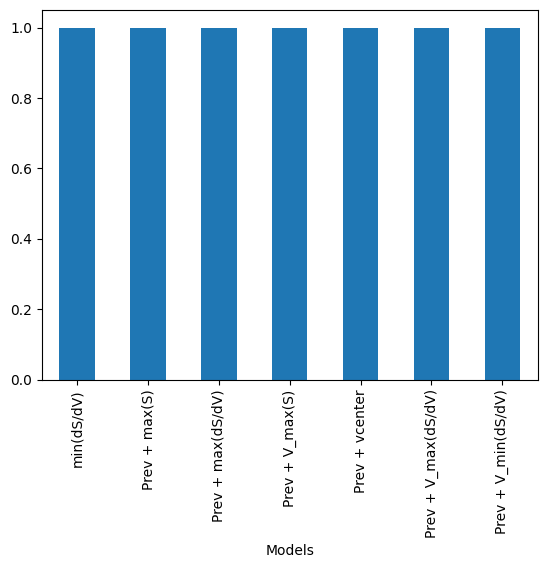

In [11]:
# List of models
models = ['KNN']
root_path = '../results/Journal_paper'


# Calcualte y_LOD
kf        = KFold(n_splits=5, shuffle=True, random_state=42)
add_alpha = False

find_class_stratified_score = True

r2_score_val,  per_diff_val  = {'Models':[], 'Scores':[]}, {'Models':[], 'Scores':[]}
r2_score_test, per_diff_test = {'Models':[], 'Scores':[]}, {'Models':[], 'Scores':[]}

r2_score_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}
per_diff_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}

metric        = 'acc'
higher_better = False if metric=='per_diff' else True

cross_feature_score = {'Models':[], 'Feature_Selected_ON':[], 'Feature_set':[], 'Other_Metric_Score':[]}

from time import time
for model_name in tqdm(models):

    starttime         = time()
    model             = ModelSelection(model_name, X_train, y_train, is_classifier=True)
    selected_features, best_params = model.find_best_features(kf, 
                                                              metric=metric, 
                                                              use_adjusted_r2=True, 
                                                              tune_hyperparameter=True)

    df                     = feature_selection_tabularize(selected_features)
    df['best_params_list'] = best_params + [{}]*(len(df)- len(best_params))

    # Store the feature selection step in a Excel sheet
    feature_selected_excel_save_path = f'{root_path}/Feature_selection/{model_name}_feature_selection_{metric}.xlsx'
    os.makedirs(os.path.dirname(feature_selected_excel_save_path), exist_ok=True)
    df.to_excel(feature_selected_excel_save_path)
    
    best_score_feature_set = get_best_score_per_feature_count(selected_features, only_best=False, higher_better=higher_better)

    save_path = f'{root_path}/Comparison_barchart/{model_name}_{metric}.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    best_score_df = pd.DataFrame(best_score_feature_set, columns=["Models", "Scores"])
    plot_model_vs_score(best_score_df, metric, save_path)

    # Train the model and calculate different metric scores.
    selected_feature_set = [(i[0].split('+')[-1]).strip() for i in best_score_feature_set]

    cross_feature_score['Models'].append(model_name)
    cross_feature_score['Feature_Selected_ON'].append(f'{metric} : {round(best_score_feature_set[-1][-1], 4)}')
    cross_feature_score['Feature_set'].append(selected_feature_set)

    temp_holder = []
    for test_metric in ['r2', 'combine', 'per_diff']:
        if (metric != test_metric):
            if model_name != 'Linear':
                model.model.set_params(**best_params[-1]) # Set the best hyper parameter
                
            score = model.find_score_KFold(kf, selected_feature_set, test_metric, use_adjusted_r2=True)
            temp_holder.append(f'{test_metric}: {round(score, 4)}')

    cross_feature_score['Other_Metric_Score'].append(' | '.join(temp_holder))

    print(f"Model name: {model_name} | Run Time: {time() - starttime}")

cross_metric_evaluation_results_path = os.path.join(root_path, f'Cross_Feature_Set/feature_selected_on_{metric}.xlsx')
os.makedirs(os.path.dirname(cross_metric_evaluation_results_path), exist_ok=True)
cross_feature_set_df = pd.DataFrame(cross_feature_score)
cross_feature_set_df.to_excel(cross_metric_evaluation_results_path)

In [ ]:
cross_metric_evaluation_results_path = os.path.join(root_path, f'Cross_Feature_Set/feature_selected_on_{metric}.xlsx')
os.makedirs(os.path.dirname(cross_metric_evaluation_results_path), exist_ok=True)
cross_feature_set_df = pd.DataFrame(cross_feature_score)
cross_feature_set_df.to_excel(cross_metric_evaluation_results_path)df

In [ ]:
len(y_train[y_train==0]), len(y_train[y_train==1])

In [10]:
model = select_model_classifier('KNN')
model.fit(X_train[['min(dS/dV)']], y_train)

y_pred = model.predict(X_test[['min(dS/dV)']])
print(np.mean(y_pred==y_test))

with open('../../weights/Journal_paper/classification_weight.pkl', 'wb') as f:
    dump(model, f)

0.9888888888888889


In [7]:
model  = select_model_classifier('SVM')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
np.mean(y_pred==y_test)

0.8333333333333334

In [8]:
model  = select_model_classifier('RF')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
np.mean(y_pred==y_test)

0.9777777777777777

In [9]:
model  = select_model_classifier('RF')
model.fit(X_train[['min(dS/dV)']], y_train)
y_pred = model.predict(X_test[['min(dS/dV)']])
print(np.mean(y_pred==y_test))

with open('../../weights/Journal_paper/classification_weight.pkl', 'wb') as f:
    dump(model, f)

0.9888888888888889


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

In [ ]:
feature_selected_excel_save_path